# MiniProject 1 - Word Frequency Analysis

## Question

I wanted to compare word frequencies between Arthur Conan Doyle and H. G. Wells.

I used two books from each author:

**Arthur Conan Doyle**
- The Adventures of Sherlock Holmes
- The Hound of the Baskervilles

**H. G. Wells**
- The Time Machine
- The War of the Worlds

I wanted to compare the two works by each author first, then compare the authors to see if there were words that one author used noticeably more often than the other.

## Approach

I downloaded the four books as plain text from Project Gutenberg. I removed the Project Gutenberg header and footer, converted the text to lowercase, and split it into individual words.

I removed common stop words so that words such as "the" and "and" would not dominate the results. After looking at the first results, I expanded the stop-word list because several common words were still appearing at the top.

Since the books have different lengths, I normalized the word counts as occurrences per 10,000 words instead of comparing raw counts.

I then compared:
1. Doyle's two books with each other.
2. Wells' two books with each other.
3. The average frequencies for Doyle against the average frequencies for Wells.

In [1]:
import re
import requests
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
books = {
    "Sherlock Holmes": "https://www.gutenberg.org/cache/epub/1661/pg1661.txt",
    "Hound of the Baskervilles": "https://www.gutenberg.org/cache/epub/2852/pg2852.txt",
    "The Time Machine": "https://www.gutenberg.org/cache/epub/35/pg35.txt",
    "The War of the Worlds": "https://www.gutenberg.org/cache/epub/36/pg36.txt"
}

for title, url in books.items():
    print(title, "-", url)

Sherlock Holmes - https://www.gutenberg.org/cache/epub/1661/pg1661.txt
Hound of the Baskervilles - https://www.gutenberg.org/cache/epub/2852/pg2852.txt
The Time Machine - https://www.gutenberg.org/cache/epub/35/pg35.txt
The War of the Worlds - https://www.gutenberg.org/cache/epub/36/pg36.txt


In [3]:
texts = {}

for title, url in books.items():
    response = requests.get(url)
    response.raise_for_status()
    texts[title] = response.text
    print(title, "-", len(response.text), "characters")

Sherlock Holmes - 593911 characters
Hound of the Baskervilles - 381207 characters
The Time Machine - 202504 characters
The War of the Worlds - 363440 characters


In [4]:
def strip_gutenberg(text):
    start = text.find("*** START OF THE PROJECT GUTENBERG EBOOK")
    end = text.find("*** END OF THE PROJECT GUTENBERG EBOOK")

    if start != -1:
        start = text.find("\n", start) + 1
    else:
        start = 0

    if end == -1:
        end = len(text)

    return text[start:end]

clean_texts = {}

for title, text in texts.items():
    clean_texts[title] = strip_gutenberg(text)
    print(title, "-", len(clean_texts[title]), "characters after cleanup")

Sherlock Holmes - 574145 characters after cleanup
Hound of the Baskervilles - 361485 characters after cleanup
The Time Machine - 182889 characters after cleanup
The War of the Worlds - 343804 characters after cleanup


In [5]:
stop_words = {
    "the", "and", "to", "of", "a", "in", "that", "was", "he", "it",
    "his", "is", "with", "as", "i", "had", "for", "at", "by", "on",
    "be", "not", "but", "from", "you", "or", "have", "an", "this",
    "which", "they", "were", "my", "we", "her", "she", "him", "me"
}

def tokenize(text):
    words = re.findall(r"[a-z']+", text.lower())
    return [
        word for word in words
        if word not in stop_words and len(word) > 1
    ]

tokens = {}

for title, text in clean_texts.items():
    tokens[title] = tokenize(text)
    print(title, "-", len(tokens[title]), "words after cleanup")

Sherlock Holmes - 59728 words after cleanup
Hound of the Baskervilles - 34095 words after cleanup
The Time Machine - 18986 words after cleanup
The War of the Worlds - 35954 words after cleanup


In [6]:
word_counts = {}
normalized_freqs = {}

for title, word_list in tokens.items():
    counts = Counter(word_list)
    total_words = len(word_list)

    word_counts[title] = counts
    normalized_freqs[title] = {
        word: (count / total_words) * 10000
        for word, count in counts.items()
    }

    print("\n", title)
    print(counts.most_common(10))


 Sherlock Holmes
[('there', 515), ('said', 486), ('upon', 465), ('holmes', 462), ('so', 449), ('very', 400), ('your', 396), ('been', 393), ('all', 392), ('what', 390)]

 Hound of the Baskervilles
[('sir', 351), ('upon', 315), ('there', 313), ('no', 265), ('one', 247), ('so', 244), ('said', 240), ('been', 222), ('all', 216), ('man', 214)]

 The Time Machine
[('time', 207), ('then', 134), ('there', 126), ('one', 118), ('all', 118), ('into', 114), ('little', 114), ('so', 113), ('upon', 113), ('came', 107)]

 The War of the Worlds
[('there', 264), ('out', 235), ('their', 215), ('all', 210), ('one', 202), ('into', 200), ('them', 187), ('so', 185), ('no', 178), ('about', 178)]


In [7]:
more_stop_words = {
    "there", "upon", "so", "your", "been", "all", "what", "sir", "no",
    "one", "then", "into", "their", "them", "about", "out", "came",
    "very", "said", "would", "could", "should", "do", "did", "does",
    "are", "am", "has", "having", "will", "can", "if", "than", "when",
    "where", "who", "whom", "why", "how", "up", "down", "over", "under"
}

stop_words.update(more_stop_words)

tokens = {}

for title, text in clean_texts.items():
    tokens[title] = tokenize(text)

    counts = Counter(tokens[title])
    print("\n", title)
    print(counts.most_common(10))


 Sherlock Holmes
[('holmes', 462), ('man', 305), ('mr', 275), ('little', 269), ('some', 244), ('now', 234), ('see', 229), ('our', 208), ('well', 201), ('may', 197)]

 Hound of the Baskervilles
[('man', 214), ('our', 205), ('holmes', 195), ('us', 182), ('moor', 165), ('henry', 157), ('some', 141), ('more', 137), ('know', 118), ('now', 118)]

 The Time Machine
[('time', 207), ('little', 114), ('some', 94), ('machine', 88), ('saw', 88), ('now', 79), ('these', 74), ('like', 74), ('seemed', 72), ('man', 71)]

 The War of the Worlds
[('martians', 166), ('people', 159), ('its', 153), ('saw', 131), ('towards', 129), ('man', 127), ('through', 124), ('time', 122), ('black', 122), ('some', 118)]


In [8]:
word_counts = {}
normalized_freqs = {}

for title, word_list in tokens.items():
    counts = Counter(word_list)
    total_words = len(word_list)

    word_counts[title] = counts
    normalized_freqs[title] = {
        word: (count / total_words) * 10000
        for word, count in counts.items()
    }

print("Normalized frequencies recalculated.")

Normalized frequencies recalculated.


In [9]:
doyle_books = ["Sherlock Holmes", "Hound of the Baskervilles"]

common_doyle_words = set(normalized_freqs[doyle_books[0]]) & set(normalized_freqs[doyle_books[1]])

doyle_combined = {
    word: normalized_freqs[doyle_books[0]][word] + normalized_freqs[doyle_books[1]][word]
    for word in common_doyle_words
}

top_doyle_words = sorted(
    doyle_combined,
    key=doyle_combined.get,
    reverse=True
)[:10]

for word in top_doyle_words:
    print(
        word,
        "- Sherlock:",
        round(normalized_freqs["Sherlock Holmes"][word], 2),
        "| Hound:",
        round(normalized_freqs["Hound of the Baskervilles"][word], 2)
    )

holmes - Sherlock: 94.84 | Hound: 70.93
man - Sherlock: 62.61 | Hound: 77.85
our - Sherlock: 42.7 | Hound: 74.57
us - Sherlock: 37.57 | Hound: 66.21
some - Sherlock: 50.09 | Hound: 51.29
now - Sherlock: 48.03 | Hound: 42.92
see - Sherlock: 47.01 | Hound: 41.11
more - Sherlock: 35.72 | Hound: 49.84
well - Sherlock: 41.26 | Hound: 40.38
mr - Sherlock: 56.45 | Hound: 22.92


In [10]:
wells_books = ["The Time Machine", "The War of the Worlds"]

common_wells_words = set(normalized_freqs[wells_books[0]]) & set(normalized_freqs[wells_books[1]])

wells_combined = {
    word: normalized_freqs[wells_books[0]][word] + normalized_freqs[wells_books[1]][word]
    for word in common_wells_words
}

top_wells_words = sorted(
    wells_combined,
    key=wells_combined.get,
    reverse=True
)[:10]

for word in top_wells_words:
    print(
        word,
        "- Time Machine:",
        round(normalized_freqs["The Time Machine"][word], 2),
        "| War of the Worlds:",
        round(normalized_freqs["The War of the Worlds"][word], 2)
    )

time - Time Machine: 126.19 | War of the Worlds: 38.9
little - Time Machine: 69.5 | War of the Worlds: 35.72
saw - Time Machine: 53.65 | War of the Worlds: 41.77
some - Time Machine: 57.3 | War of the Worlds: 37.63
its - Time Machine: 42.06 | War of the Worlds: 48.79
man - Time Machine: 43.28 | War of the Worlds: 40.5
these - Time Machine: 45.11 | War of the Worlds: 36.67
now - Time Machine: 48.16 | War of the Worlds: 33.16
people - Time Machine: 28.04 | War of the Worlds: 50.7
like - Time Machine: 45.11 | War of the Worlds: 30.29


In [11]:
all_words = set()

for title in normalized_freqs:
    all_words.update(normalized_freqs[title].keys())

doyle_avg = {}
wells_avg = {}

for word in all_words:
    doyle_avg[word] = (
        normalized_freqs["Sherlock Holmes"].get(word, 0) +
        normalized_freqs["Hound of the Baskervilles"].get(word, 0)
    ) / 2

    wells_avg[word] = (
        normalized_freqs["The Time Machine"].get(word, 0) +
        normalized_freqs["The War of the Worlds"].get(word, 0)
    ) / 2

differences = {
    word: doyle_avg[word] - wells_avg[word]
    for word in all_words
}

most_doyle = sorted(differences, key=differences.get, reverse=True)[:10]
most_wells = sorted(differences, key=differences.get)[:10]

print("Words used more by Doyle:")
for word in most_doyle:
    print(word, "-", round(doyle_avg[word], 2), "vs.", round(wells_avg[word], 2))

print("\nWords used more by Wells:")
for word in most_wells:
    print(word, "-", round(doyle_avg[word], 2), "vs.", round(wells_avg[word], 2))

Words used more by Doyle:
holmes - 82.89 vs. 0.0
mr - 39.68 vs. 0.3
moor - 30.01 vs. 0.0
watson - 29.59 vs. 0.0
henry - 29.58 vs. 0.0
man - 70.23 vs. 41.89
well - 40.82 vs. 15.42
our - 58.63 vs. 33.48
us - 51.89 vs. 26.93
know - 38.91 vs. 15.38

Words used more by Wells:
time - 31.14 vs. 82.55
people - 6.57 vs. 39.37
machine - 1.64 vs. 34.0
towards - 6.24 vs. 34.89
saw - 20.23 vs. 47.71
martians - 0.0 vs. 26.47
its - 19.92 vs. 45.43
seemed - 13.63 vs. 36.61
these - 20.22 vs. 40.89
traveller - 0.21 vs. 19.81


## Results

### Doyle vs. Wells

The comparison showed several large differences between the authors. Doyle used words such as "holmes," "watson," "moor," and "henry" much more frequently, while Wells used words such as "time," "machine," "martians," and "traveller" more frequently.

There were also differences in words that were less directly connected to characters or settings. For example, "man" appeared about 70 times per 10,000 words for Doyle compared with about 42 for Wells. The word "saw" appeared about 20 times per 10,000 words for Doyle compared with about 48 for Wells.

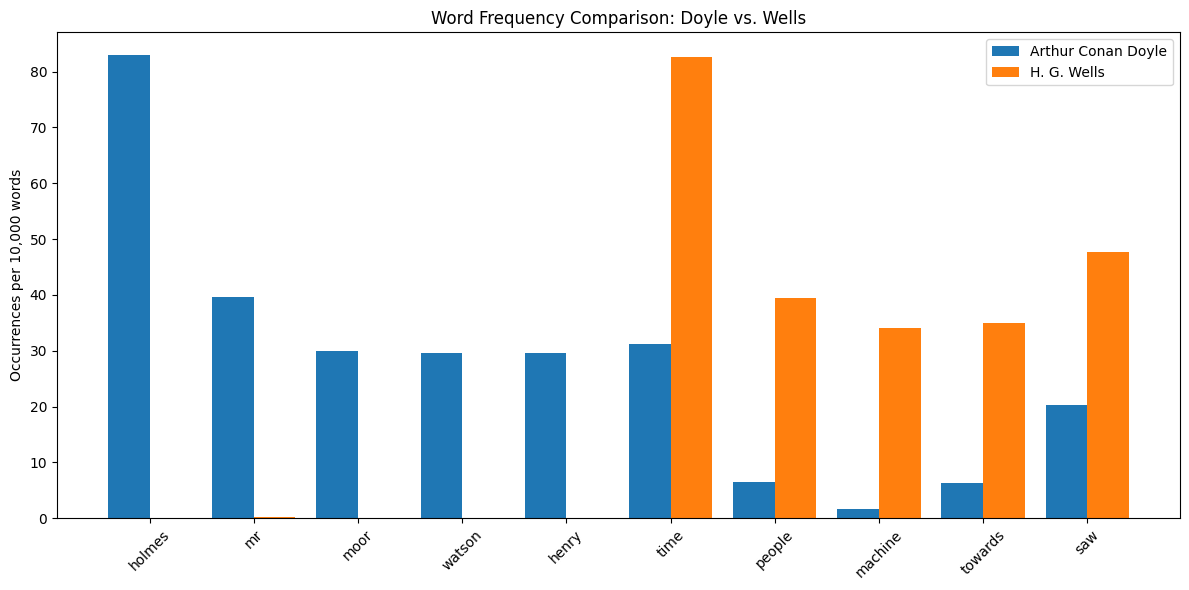

In [12]:
words = most_doyle[:5] + most_wells[:5]

doyle_values = [doyle_avg[word] for word in words]
wells_values = [wells_avg[word] for word in words]

x = range(len(words))
width = 0.4

plt.figure(figsize=(12, 6))

plt.bar([i - width/2 for i in x], doyle_values, width, label="Arthur Conan Doyle")
plt.bar([i + width/2 for i in x], wells_values, width, label="H. G. Wells")

plt.xticks(x, words, rotation=45)
plt.ylabel("Occurrences per 10,000 words")
plt.title("Word Frequency Comparison: Doyle vs. Wells")
plt.legend()

plt.tight_layout()
plt.show()

### Comparing Doyle's Two Works

Some words had similar frequencies between Doyle's two books, while others changed considerably. For example, "some" and "well" had very similar normalized frequencies in both books. Words such as "our," "us," and "mr" showed larger differences.

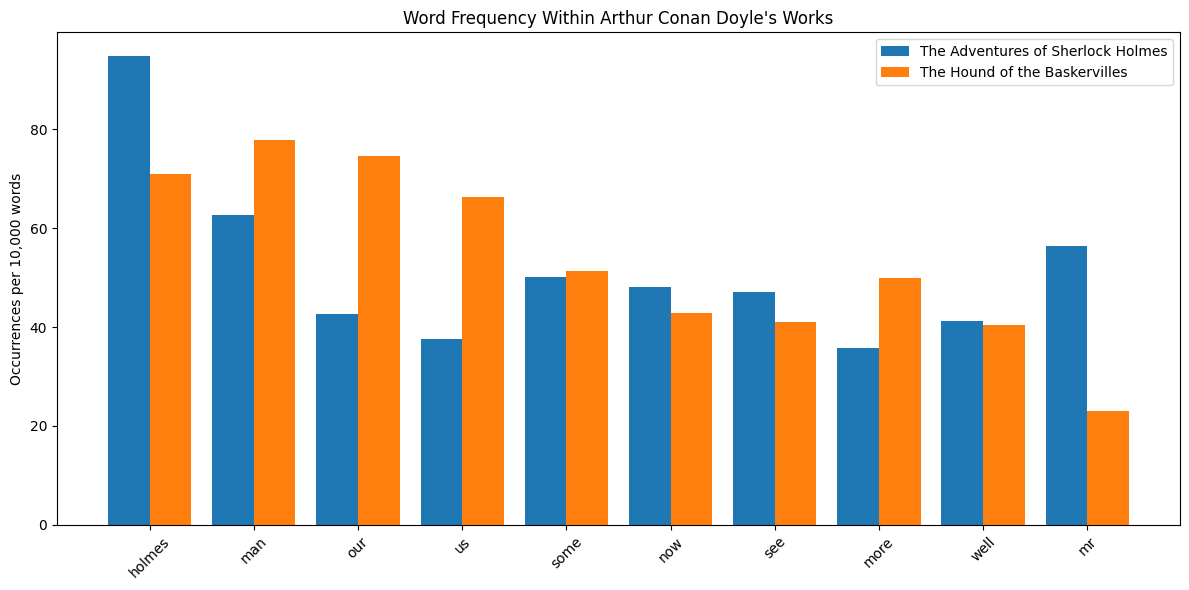

In [13]:
words = top_doyle_words

sherlock_values = [
    normalized_freqs["Sherlock Holmes"][word]
    for word in words
]

hound_values = [
    normalized_freqs["Hound of the Baskervilles"][word]
    for word in words
]

x = range(len(words))
width = 0.4

plt.figure(figsize=(12, 6))

plt.bar([i - width/2 for i in x], sherlock_values, width,
        label="The Adventures of Sherlock Holmes")

plt.bar([i + width/2 for i in x], hound_values, width,
        label="The Hound of the Baskervilles")

plt.xticks(x, words, rotation=45)
plt.ylabel("Occurrences per 10,000 words")
plt.title("Word Frequency Within Arthur Conan Doyle's Works")
plt.legend()

plt.tight_layout()
plt.show()

### Comparing Wells' Two Works

Wells also showed differences between his two books. The largest example was "time," which appeared about 126 times per 10,000 words in The Time Machine but only about 39 times per 10,000 words in The War of the Worlds.

This suggests that the subject of an individual book can have a large effect on its most frequent words.

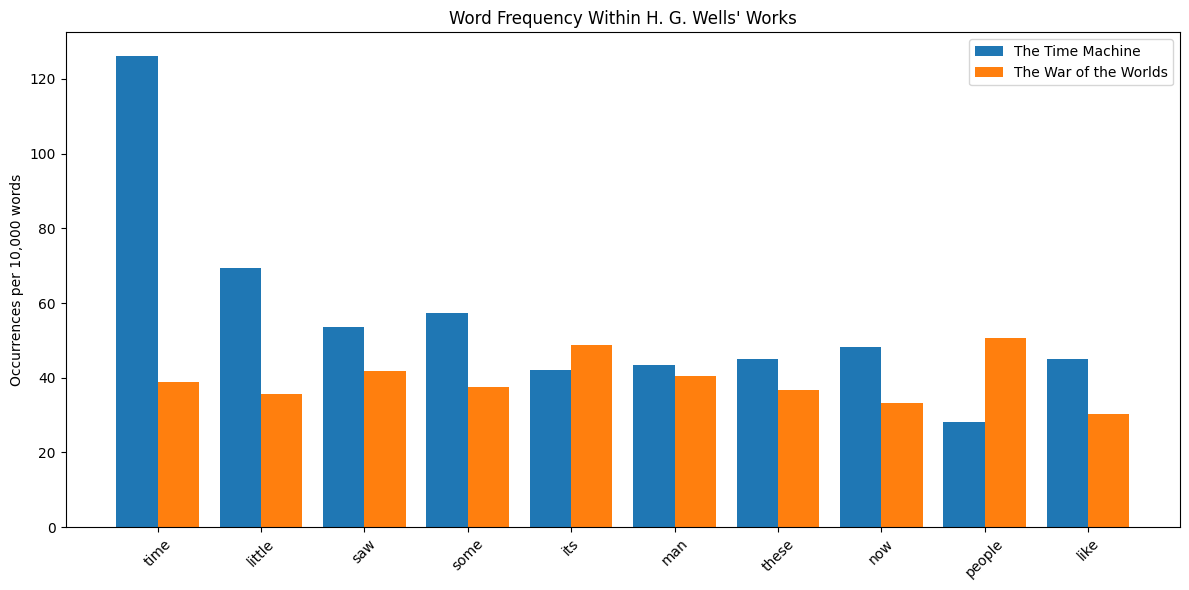

In [14]:
words = top_wells_words

time_machine_values = [
    normalized_freqs["The Time Machine"][word]
    for word in words
]

war_worlds_values = [
    normalized_freqs["The War of the Worlds"][word]
    for word in words
]

x = range(len(words))
width = 0.4

plt.figure(figsize=(12, 6))

plt.bar([i - width/2 for i in x], time_machine_values, width,
        label="The Time Machine")

plt.bar([i + width/2 for i in x], war_worlds_values, width,
        label="The War of the Worlds")

plt.xticks(x, words, rotation=45)
plt.ylabel("Occurrences per 10,000 words")
plt.title("Word Frequency Within H. G. Wells' Works")
plt.legend()

plt.tight_layout()
plt.show()

## Problems and Limitations

One problem I ran into was that my original stop-word list was too small. Common words such as "there," "upon," and "so" were still dominating the results, so I expanded the list before doing the comparisons.

A major limitation is that word frequency does not necessarily represent an author's writing style by itself. Many of the largest differences were caused by characters and subject matter. For example, "holmes" and "watson" are strongly associated with Doyle's stories, while "time," "machine," and "martians" are connected to the subjects of Wells' books.

I also only used two books from each author, so the results cannot represent everything each author wrote.

## Conclusion

The analysis found clear differences in word frequencies both between books by the same author and between Doyle and Wells. Some words were relatively consistent within an author's works, while others changed substantially depending on the book.

The results show that normalized word frequency can identify differences between authors, but those differences have to be interpreted carefully because the topic of each book can strongly influence the results.

## New Ideas

A larger analysis could use more books from each author to reduce the effect of individual stories. It could also remove character names and other book-specific terms before comparing the authors. This might make it easier to find differences that are more closely related to writing style.